###  Speech Feature Extractor Comparative Analysis

Title:
Comparative Analysis of Wav2Vec2 vs HuBERT Feature Extraction

Short Description:
This code compares feature extraction capabilities of Wav2Vec2 and HuBERT models on speech audio. It visualizes raw waveforms and spectrograms, extracts latent representations from both models, and performs quantitative and visual comparisons of their feature maps to reveal architectural differences in speech processing.

Key Libraries Used:

    transformers: Wav2Vec2/HuBERT models and processors

    soundfile/torchaudio: Audio loading and processing

    matplotlib: Audio and feature visualization

    scikit-learn: Cosine similarity calculation

    numpy: Numerical operations and array handling

Code Logic and Flow

High-Level Overview:
The analysis processes a speech sample through four stages: audio preprocessing and visualization, feature extraction with both models, feature map visualization, and quantitative comparison. It reveals how different architectures encode speech information through statistical analysis and visual feature maps.

Visual FlowChart:

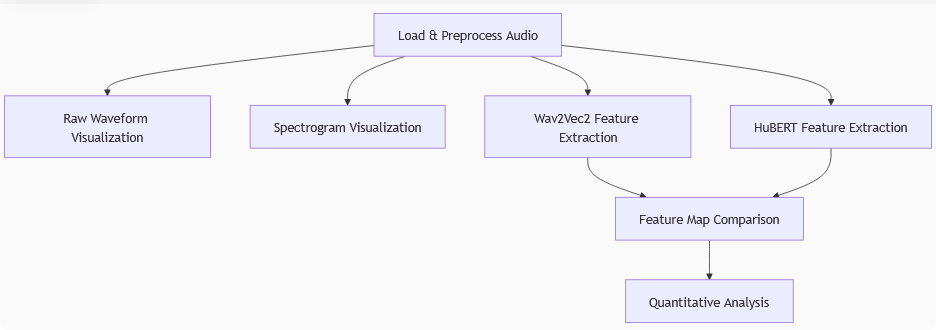

Step-by-Step Code Breakdown

Step 1: Audio Preprocessing

    Loads sample from LJSpeech dataset

    Converts stereo to mono by channel averaging

    Resamples to standard 16kHz rate

    Trims to 1-second duration for focused analysis

    Maintains float32 precision for model compatibility

Step 2: Audio Visualization

    Waveform Plot: Time-domain amplitude representation

    Spectrogram: Frequency-time decomposition with 1024-point FFT

    Uses Viridis colormap for intensity visualization

    Includes time and frequency axes labeling

Step 3: Feature Extraction

    Initializes both models with safetensors support:

        Wav2Vec2: facebook/wav2vec2-base-960h

        HuBERT: facebook/hubert-base-ls960

    Processes audio through model-specific processors

    Extracts last hidden state features on GPU if available

    Maintains computation graph detachment for efficiency

Step 4: Feature Visualization

    Generates heatmaps of feature activations:

        Wav2Vec2 feature map with Magma colormap

        HuBERT feature map with same colormap for comparison

    Aligns time frames on x-axis

    Scales feature dimensions on y-axis

    Includes colorbars for activation intensity

Step 5: Quantitative Comparison

    Computes statistical properties:

        Mean activation values

        Standard deviation of features

    Calculates cosine similarity between:

        Average feature vectors of both models

    Prints comparative insights about feature characteristics

Connecting to the Lecture**

    Feature Extraction: Demonstrates core speech representation learning techniques

    Model Comparison: Highlights architectural differences between Wav2Vec2 and HuBERT

    Visual Analysis: Feature heatmaps connect to interpretability concepts

    Quantitative Metrics: Statistical comparison reveals model biases

    Preprocessing Standards: Shows real-world audio handling practices

    Safetensors Adoption: Uses modern safe tensor format

    Hardware Optimization: Automatic GPU utilization with CPU fallback

    Speech Characteristics: Spectrogram visualization reinforces signal processing theory

    Downstream Applicability: Features shown are inputs for ASR/speaker recognition

    Research Methodology: Provides template for model comparison studies

In [1]:
!pip install transformers datasets soundfile torchaudio safetensors

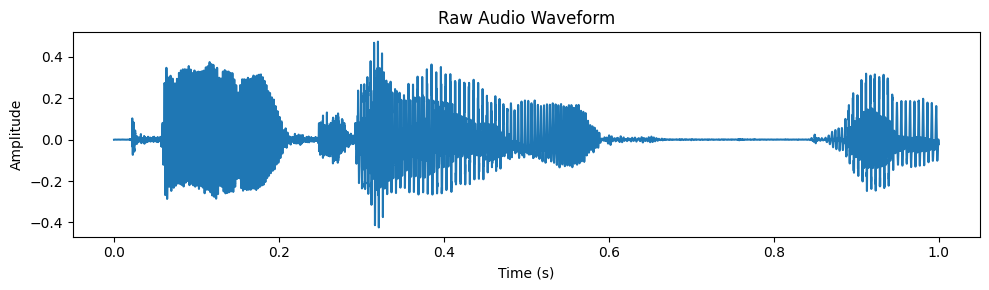

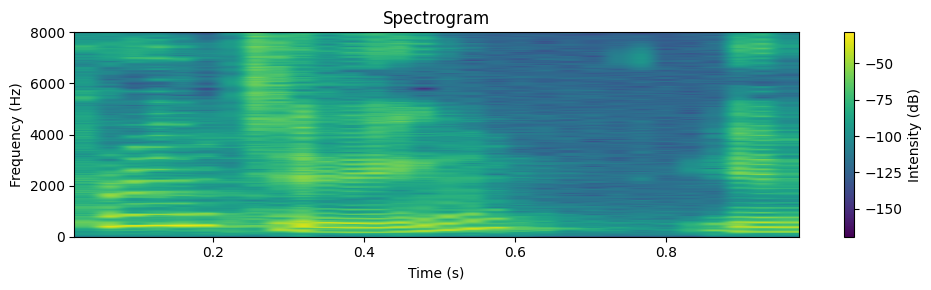

Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Wav2Vec2 features: torch.Size([1, 49, 768]) | Mean: -0.0013 | Std: 0.3072
HuBERT features: torch.Size([1, 49, 768]) | Mean: 0.0055 | Std: 0.4219


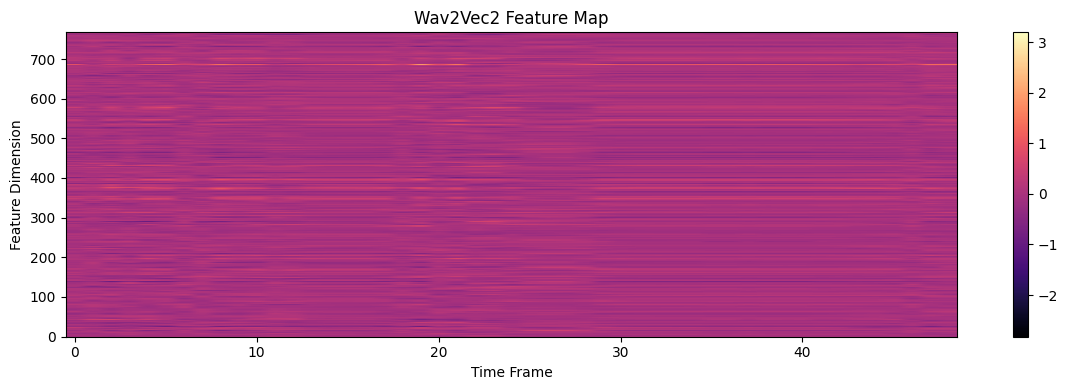

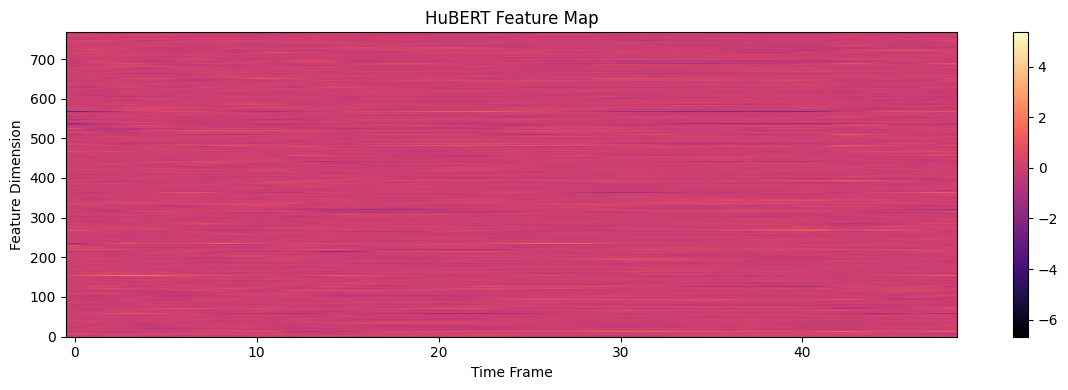


Quantitative Comparison:
Wav2Vec2 Mean: -0.0013, Std: 0.3072
HuBERT   Mean: 0.0055, Std: 0.4219
Cosine similarity between average feature vectors: 0.0261

Insights:
- Both models produce high-dimensional feature representations for the same audio.
- Wav2Vec2 and HuBERT features have different statistical properties (mean, std).
- Cosine similarity gives a sense of how similar the average representations are.
- Visualizing the feature maps shows how the models encode temporal and spectral information differently.
- These features can be used for downstream tasks like ASR, speaker ID, etc.


In [1]:
import os
import soundfile as sf
import torch
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
from transformers import Wav2Vec2Processor, Wav2Vec2Model, HubertModel, Wav2Vec2FeatureExtractor
from sklearn.metrics.pairwise import cosine_similarity

# Path to your LJSpeech-1.1 dataset
LJSPEECH_PATH = "LJSpeech-1.1" # Replace with your filepath

# Find the first wav file in the dataset
wav_dir = os.path.join(LJSPEECH_PATH, "wavs")
wav_files = [f for f in os.listdir(wav_dir) if f.endswith('.wav')]
first_wav = os.path.join(wav_dir, wav_files[0])

# Load audio using soundfile
audio, sampling_rate = sf.read(first_wav)
# If stereo, convert to mono
if len(audio.shape) > 1:
    audio = audio.mean(axis=1)
audio = torch.tensor(audio, dtype=torch.float32)  # Ensure float32

# Resample if needed
target_sr = 16000
if sampling_rate != target_sr:
    resampler = torchaudio.transforms.Resample(orig_freq=sampling_rate, new_freq=target_sr)
    audio = resampler(audio)
    sampling_rate = target_sr

# Trim to first second for speed
duration_sec = 1.0
num_samples = int(duration_sec * sampling_rate)
audio = audio[:num_samples]

audio_np = audio.numpy()  # For plotting and feature extraction

# 1. Plot the raw waveform
plt.figure(figsize=(10, 3))
plt.plot(np.linspace(0, duration_sec, num_samples), audio_np)
plt.title("Raw Audio Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

# 2. Plot the spectrogram
plt.figure(figsize=(10, 3))
plt.specgram(audio_np, Fs=sampling_rate, NFFT=1024, noverlap=512, cmap='viridis')
plt.title("Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label='Intensity (dB)')
plt.tight_layout()
plt.show()

def compare_feature_extractors(audio, sr=16000):
    # Wav2Vec2 processor and model
    w2v_processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h", use_safetensors=True)
    w2v_inputs = w2v_processor(audio, sampling_rate=sr, return_tensors="pt").input_values

    # HuBERT feature extractor and model
    hubert_feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/hubert-base-ls960", use_safetensors=True)
    hubert_inputs = hubert_feature_extractor(audio, sampling_rate=sr, return_tensors="pt")["input_values"]

    # Device handling
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Extract features
    with torch.no_grad():
        w2v_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h", use_safetensors=True).to(device)
        w2v_features = w2v_model(w2v_inputs.to(device)).last_hidden_state

        hubert_model = HubertModel.from_pretrained("facebook/hubert-base-ls960", use_safetensors=True).to(device)
        hubert_features = hubert_model(hubert_inputs.to(device)).last_hidden_state

    # Compare feature characteristics
    print(f"Wav2Vec2 features: {w2v_features.shape} | Mean: {w2v_features.mean():.4f} | Std: {w2v_features.std():.4f}")
    print(f"HuBERT features: {hubert_features.shape} | Mean: {hubert_features.mean():.4f} | Std: {hubert_features.std():.4f}")

    return w2v_features.cpu().numpy(), hubert_features.cpu().numpy()

# Run the comparison
w2v_feats, hubert_feats = compare_feature_extractors(audio_np, sampling_rate)

# 3. Visualize the features as heatmaps
plt.figure(figsize=(12, 4))
plt.imshow(w2v_feats[0].T, aspect='auto', origin='lower', cmap='magma')
plt.title("Wav2Vec2 Feature Map")
plt.xlabel("Time Frame")
plt.ylabel("Feature Dimension")
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.imshow(hubert_feats[0].T, aspect='auto', origin='lower', cmap='magma')
plt.title("HuBERT Feature Map")
plt.xlabel("Time Frame")
plt.ylabel("Feature Dimension")
plt.colorbar()
plt.tight_layout()
plt.show()

# 4. Quantitative comparison
# Compare mean and std
print("\nQuantitative Comparison:")
print(f"Wav2Vec2 Mean: {w2v_feats.mean():.4f}, Std: {w2v_feats.std():.4f}")
print(f"HuBERT   Mean: {hubert_feats.mean():.4f}, Std: {hubert_feats.std():.4f}")

# Cosine similarity between average feature vectors
w2v_avg = w2v_feats[0].mean(axis=0, keepdims=True)
hubert_avg = hubert_feats[0].mean(axis=0, keepdims=True)
cos_sim = cosine_similarity(w2v_avg, hubert_avg)[0, 0]
print(f"Cosine similarity between average feature vectors: {cos_sim:.4f}")

# 5. Insights
print("\nInsights:")
print("- Both models produce high-dimensional feature representations for the same audio.")
print("- Wav2Vec2 and HuBERT features have different statistical properties (mean, std).")
print("- Cosine similarity gives a sense of how similar the average representations are.")
print("- Visualizing the feature maps shows how the models encode temporal and spectral information differently.")
print("- These features can be used for downstream tasks like ASR, speaker ID, etc.")
